# Simulation of LUCJ circuits

In [1]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf

import qiskit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap
from qiskit.quantum_info import Statevector, SparsePauliOp, DensityMatrix

## Parameters

In [2]:
atom: str = "H"
natoms: int = 4
nlayers: int = 1  # Number of layers in the ansatz.

damping: float = 0.00
cutoff: float = 0
nthreads: int = 1

## Problem defintion

### Molecule

In [3]:
def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.
    
    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

In [4]:
# Specify molecule properties
spin_sq = 0

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

# Compute exact energy using FCI
# reference_energy = cas.run().e_tot

print(f"norb = {norb}")
print(f"nelec = {nelec}")

converged SCF energy = -2.11246069891457
norb = 4
nelec = (2, 2)


## Circuit construction

In [5]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

E(CCSD) = -2.180959042273996  E_corr = -0.06849834335942971


In [6]:
coupling_map = CouplingMap.from_grid(
    num_rows=int(np.ceil(np.sqrt(2 * norb))),
    num_columns=int(np.ceil(np.sqrt(2 * norb)))
)
backend = GenericBackendV2(
    coupling_map.size(),
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

In [7]:
pairs_aa = [(p, p + 1) for p in range(norb - 1)]
pairs_ab = [(p, p) for p in range(norb)]  # None  # Let generate_lucj_pass_manager determine the alpha-beta interactions

In [8]:
# Create pass manager
try:
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="square",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
    )
    print("Unable to generate ffsim pass manager")
except RuntimeError:
    pass_manager = None

print("pairs_aa:", pairs_aa)
print("pairs_ab:", pairs_ab)

Unable to generate ffsim pass manager
pairs_aa: [(0, 1), (1, 2), (2, 3)]
pairs_ab: [(0, 0), (1, 1)]


/Users/ryan/prof/work/lucj/envpropaq/lib/python3.10/site-packages/ffsim/qiskit/lucj_pass_manager.py:160: UserWarning: Backend cannot accommodate pairs_ab=[(0, 0), (1, 1), (2, 2), (3, 3)].
Removing interaction (3, 3) from the end.
  warnings.warn(
/Users/ryan/prof/work/lucj/envpropaq/lib/python3.10/site-packages/ffsim/qiskit/lucj_pass_manager.py:160: UserWarning: Backend cannot accommodate pairs_ab=[(0, 0), (1, 1), (2, 2)].
Removing interaction (2, 2) from the end.
  warnings.warn(


In [9]:
# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=nlayers,
    interaction_pairs=(pairs_aa, pairs_ab),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    # Limit the number of optimization iterations to prevent the code cell from running
    # too long. Removing this line may improve results.
    options=dict(maxiter=1000),
)

qubits = qiskit.QuantumRegister(2 * norb, name="q")
circuit = qiskit.QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)

In [10]:
if pass_manager is not None:
    compiled = pass_manager.run(circuit)
else:
    compiled = qiskit.transpile(circuit, backend=backend, optimization_level=3)

In [11]:
print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")

Number of qubits: 9
Gate counts: OrderedDict([('xx_plus_yy', 20), ('cp', 8), ('p', 8), ('x', 4)])


In [12]:
compiled.draw(fold=-1)

┌───┐                                                                                       ┌──────────────────┐                                                                                                                          ┌──────────────────────────┐                                                                                                                                            ┌──────────────────────────┐       ┌────────────┐                     
q_4 -> 0 ┤ X ├───────────────────────────────────────────────────────────────────────────────────────┤1                 ├────────────────────────────────────────────────────■─────────────■───────────────────────────────────────────────────────┤1                         ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤1                         ├───────┤ P(-1.4041) ├─────────────────────
         ├───┤                                                                  ┌──────────────────┐ │                  │                                                    │             │P(-0.7841)                                             │                          │┌──────────────────────────┐                                                        ┌──────────────────────────┐       ┌────────────┐       │                          │       └────────────┘                     
q_0 -> 1 ┤ X ├──────────────────────────────────────────────────────────────────┤1                 ├─┤                  ├────────────────────────■───────────────────────────┼─────────────■───────────────────────────────────────────────────────┤                          ├┤1                         ├────────────────────────────────────────────────────────┤1                         ├───────┤ P(-1.4041) ├───────┤                          ├──────────────────────────────────────────
         └───┘                                              ┌──────────────────┐│                  │ │  (XX+YY)(π,-π/2) │                        │                           │                          ┌──────────────────────────┐               │  (XX+YY)(0.009075,-3π/4) ││                          │                                                        │                          │┌──────┴────────────┴──────┐│  (XX+YY)(3.1305,-3.3084) │       ┌────────────┐                     
q_3 -> 2 ───────────────────────────────────────────────────┤0                 ├┤                  ├─┤                  ├────────────────────────┼─────────────■─────────────┼──────────────────────────┤0                         ├───────────────┤                          ├┤                          ├────────────────────────────────────────────────────────┤                          ├┤1                         ├┤                          ├───────┤ P(-2.1895) ├─────────────────────
         ┌───┐                       ┌─────────────────────┐│                  ││  (XX+YY)(π,-π/2) │ │                  │ ┌────────────────────┐ │             │             │P(-0.10062)               │                          │               │                          ││  (XX+YY)(0.009075,-3π/4) │                            ┌──────────────────────────┐│  (XX+YY)(3.1305,-3.3084) ││                          ││                          │┌──────┴────────────┴──────┐┌────────────┐
q_5 -> 3 ┤ X ├───────────────────────┤1                    ├┤                  ├┤                  ├─┤0                 ├─┤1                   ├─┼─────────────┼─────────────■─────────────■────────────┤                          ├─■─────────────┤0                         ├┤                          ├────────────────────────────┤1                         ├┤                          ├┤                          ├┤0                         ├┤0                         ├┤ P(-1.7376) ├
         ├───┤┌─────────────────────┐│                     ││  (XX+YY)(π,-π/2) ││                  │┌┴──────────────────┴┐│                    │ │P(-0.10

## Observable definition

In [13]:
observables = [
    SparsePauliOp("ZZ" + "I" * (compiled.num_qubits - 2)),
    SparsePauliOp("I" * (compiled.num_qubits // 2) + "ZZ" + "I" * (compiled.num_qubits // 2 - 2)),
    SparsePauliOp("I" * (compiled.num_qubits - 2) + "ZZ")
]

### Exact values

In [14]:
if compiled.num_qubits <= 20:
    expectation_values_exact = []
    for observable in observables:
        statevector = Statevector(compiled)
        sv_expectation_value = statevector.expectation_value(observable).real
        print(sv_expectation_value)
        expectation_values_exact.append(sv_expectation_value)

0.9943378732971792
-0.8452941716773749
0.9891971616735132


### Noisy values

In [15]:
from qiskit_aer.noise import depolarizing_error
from qiskit.converters import circuit_to_dag, dag_to_circuit

In [16]:
noisy = compiled.copy_empty_like()
for layer in circuit_to_dag(compiled).layers():
    noisy.compose(dag_to_circuit(layer["graph"]), inplace=True)
    noisy.barrier()
    for qubit in noisy.qubits:
        noisy.append(depolarizing_error(3 / 4 * (1 - np.exp(-damping)), 1), [qubit])  # TODO: Triple check channel rate.
    noisy.barrier()


noisy.draw(fold=-1)

┌───┐ ░ ┌─────────────────┐ ░                                                ░ ┌─────────────────┐ ░ ┌──────────────────┐                                         ░ ┌─────────────────┐ ░                                              ░ ┌─────────────────┐ ░                                            ░ ┌─────────────────┐ ░                              ░ ┌─────────────────┐ ░                                                          ░ ┌─────────────────┐ ░ ┌──────────────────────────┐                             ░ ┌─────────────────┐ ░                                                          ░ ┌─────────────────┐ ░ ┌──────────────────────────┐                                                         ░ ┌─────────────────┐ ░        ┌────────────┐                                    ░ ┌─────────────────┐ ░                ░ ┌─────────────────┐ ░ 
      q_4 -> 0 ┤ X ├─░─┤ Quantum_channel ├─░────────────────────────────────────────────────░─┤ Quantum_channel ├─░─┤1                 ├─────────────────────────────────────────░─┤ Quantum_channel ├─░──────────────────────────────────────────────░─┤ Quantum_channel ├─░──■─────────────────────────────────────────░─┤ Quantum_channel ├─░──■───────────────────────────░─┤ Quantum_channel ├─░──────────────────────────────────────────────────────────░─┤ Quantum_channel ├─░─┤1                         ├─────────────────────────────░─┤ Quantum_channel ├─░──────────────────────────────────────────────────────────░─┤ Quantum_channel ├─░─┤1                         ├─────────────────────────────────────────────────────────░─┤ Quantum_channel ├─░────────┤ P(-1.4041) ├────────────────────────────────────░─┤ Quantum_channel ├─░────────────────░─┤ Quantum_channel ├─░─
               ├───┤ ░ ├─────────────────┤ ░                                                ░ ├─────────────────┤ ░ │                  │┌──────────────────┐                     ░ ├─────────────────┤ ░                                              ░ ├─────────────────┤ ░  │                                         ░ ├─────────────────┤ ░  │P(-0.7841)                 ░ ├─────────────────┤ ░                                                          ░ ├─────────────────┤ ░ │                          │┌──────────────────────────┐ ░ ├─────────────────┤ ░                                                          ░ ├─────────────────┤ ░ │                          │┌──────────────────────────┐                             ░ ├─────────────────┤ ░        ├────────────┤                                    ░ ├─────────────────┤ ░                ░ ├─────────────────┤ ░ 
      q_0 -> 1 ┤ X ├─░─┤ Quantum_channel ├─░────────────────────────────────────────────────░─┤ Quantum_channel ├─░─┤                  ├┤1                 ├─────────────────────░─┤ Quantum_channel ├─░──────────────────────────────────────────────░─┤ Quantum_channel ├─░──┼─────────────■───────────────────────────░─┤ Quantum_channel ├─░──■───────────────────────────░─┤ Quantum_channel ├─░──────────────────────────────────────────────────────────░─┤ Quantum_channel ├─░─┤                          ├┤1                         ├─░─┤ Quantum_channel ├─░──────────────────────────────────────────────────────────░─┤ Quantum_channel ├─░─┤                          ├┤1                         ├─────────────────────────────░─┤ Quantum_channel ├─░────────┤ P(-1.4041) ├────────────────────────────────────░─┤ Quantum_channel ├─░────────────────░─┤ Quantum_channel ├─░─
               └───┘ ░ ├─────────────────┤ ░                                                ░ ├─────────────────┤ ░ │  (XX+YY)(π,-π/2) ││                  │┌──────────────────┐ ░ ├─────────────────┤ ░                                              ░ ├─────────────────┤ ░  │             │                           ░ ├─────────────────┤ ░                              ░ ├─────────────────┤ ░                             ┌──────────────────────────┐ ░ ├─────────────────┤ ░ │  (XX+YY)(0.009075,-3π/4) ││                          │ ░ ├─────────────────┤ ░            

In [17]:
if noisy.num_qubits <= 10:
    rho = DensityMatrix.from_label("0" * noisy.num_qubits)
    rho = rho.evolve(noisy)

    for observable in observables:
        ev = rho.expectation_value(observable)
        print(ev)

(0.9943378732970678+0j)
(-0.8452941716772808+0j)
(0.9891971616734021+0j)


## Heisenberg simulation

In [18]:
from propaq.datatypes import MajoranaMonomial

from propaq.propagators import MajoranaPropagator, PauliPropagator
from propaq.circuits import MajoranaCircuit, PauliCircuit
from propaq.noise import UniformNoiseModel, truncation
from propaq.noise import TruncationPolicy 

from propaq.datatypes import MajoranaTermSum, PauliTermSum

### Majorana basis

In [19]:
mc = MajoranaCircuit.from_qiskit(compiled.copy(), n_modes=2 * compiled.num_qubits)

In [20]:
prop = MajoranaPropagator(
    UniformNoiseModel(damping=damping),
    TruncationPolicy(weight_cutoff=100000000, coeff_cutoff=cutoff),
    n_threads=nthreads,
    progress_bar=True,
)

In [21]:
results = []
for observable in observables:
    observable_mts = MajoranaTermSum.from_sparse_pauli_op(observable)
    results.append(prop.expectation_value(observable_mts, mc, fock_state=0))
    print(results[-1].expectation_value)

Propagating through gates:   0%|          | 0/116 [00:00<?, ?it/s]

0.9943378732971788


Propagating through gates:   0%|          | 0/116 [00:00<?, ?it/s]

-0.8452941716773762


Propagating through gates:   0%|          | 0/116 [00:00<?, ?it/s]

0.9891971616735136


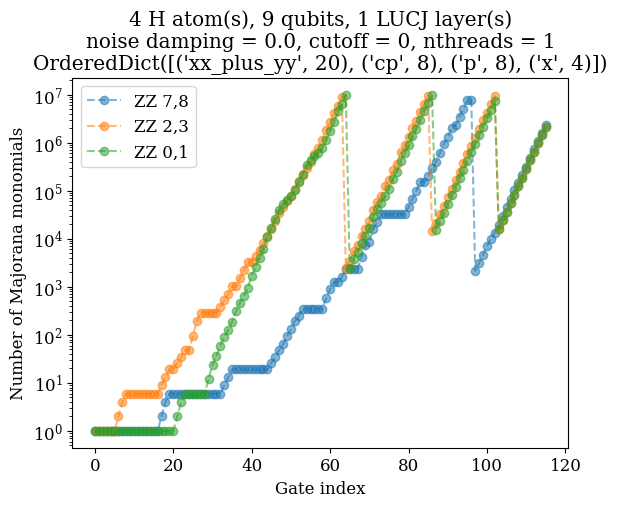

In [22]:
for i, result in enumerate(results):
    plt.semilogy(result.n_terms, "--o", alpha=0.55, label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Gate index")
plt.ylabel("Number of Majorana monomials")
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s)\nnoise damping = {damping}, cutoff = {cutoff}, nthreads = {nthreads}\n{compiled.count_ops()}")
plt.legend();

### Pauli basis

In [ ]:
pc = PauliCircuit.from_qiskit(compiled.copy())

In [ ]:
pauli = PauliPropagator(
    UniformNoiseModel(damping=damping),
    TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
    n_threads=16,
    progress_bar=True,
)

In [ ]:
pauli_results = []
for observable in observables:
    observable_mts = PauliTermSum.from_sparse_pauli_op(observable)
    pauli_results.append(pauli.expectation_value(observable_mts, pc, fock_state=0))
    print(pauli_results[-1].expectation_value)

In [ ]:
for i, result in enumerate(pauli_results):
    plt.semilogy(result.n_terms, "--o", alpha=0.55,label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Gate index")
plt.ylabel("Number of Pauli strings")
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s), noise damping = {damping}, cutoff = {cutoff}\n{compiled.count_ops()}")
plt.legend();

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=True
)

# Left subplot: Majorana monomials
ax = axes[0]

for i, result in enumerate(results):
    ax.semilogy(
        result.n_terms,
        "--o",
        alpha=0.55,
        label="ZZ " + ",".join(
            map(str, observables[i].to_sparse_list()[0][1])
        )
    )

ax.set_xlabel("Gate index")
ax.set_ylabel("Number of terms")
ax.set_title("Majorana monomials")
ax.grid(True, which="both", linestyle="--", alpha=0.75)
ax.legend()


# Right subplot: Pauli strings
ax = axes[1]

for i, result in enumerate(pauli_results):
    ax.semilogy(
        result.n_terms,
        "--o",
        alpha=0.55,
        label="ZZ " + ",".join(
            map(str, observables[i].to_sparse_list()[0][1])
        )
    )

ax.set_xlabel("Gate index")
ax.set_title("Pauli strings")
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend()


fig.suptitle(
    f"{natoms} {atom} atom(s), "
    f"{len(compiled.qubits)} qubits, "
    f"{nlayers} LUCJ layer(s), "
    f"noise damping = {damping}, cutoff = {cutoff}\n"
    f"{compiled.count_ops()}"
)

plt.tight_layout()
plt.show()

## Accuracy vs coefficient cutoff threshold

In [ ]:
cutoffs = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
evals = []
for cutoff in cutoffs:
    print("On cutoff:", cutoff)
    prop = MajoranaPropagator(
        UniformNoiseModel(damping=0.00),
        TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
        n_threads=2,
        progress_bar=True,
    )
    oevals = []
    for i, observable in enumerate(observables):
        observable_mts = MajoranaTermSum.from_sparse_pauli_op(observable)
        mp_expectation_value = prop.expectation_value(observable_mts, mc, fock_state=0).expectation_value
        print(mp_expectation_value, expectation_values_exact[i])
        oevals.append(mp_expectation_value)
    evals.append(oevals)

In [ ]:
evals = np.array(evals).T

errors = []
for i, e in enumerate(evals):
    errors.append(e - expectation_values_exact[i])

errors = np.abs(np.array(errors))

In [ ]:
for i, e in enumerate(errors):
    plt.loglog(cutoffs, e, "--s", ms=9, mec="black", alpha=0.75, label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Coefficient magnitude cutoff")
plt.ylabel(f"Absolute error")
plt.legend()
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s)\n{compiled.count_ops()}");
plt.savefig("error_vs_cutoff.pdf")